In [1]:
#import libraries 
import torch 
import torch.nn as nn 
import torch.optim as optim
from matplotlib import pyplot as plt 

In [36]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0, 3.0, -4.0, 6.0, 13.0, 21.0] # temperature in celsius
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4] #temperature in unknown unit
t_c = torch.tensor(t_c).unsqueeze(1)
t_u = torch.tensor(t_u).unsqueeze(1)

# spliting data
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]
val_t_c = t_c[val_indices]
val_t_u = t_u[val_indices]
train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u 

In [37]:
"""
All PyTorch-provided subclasses of nn.Module have their __call__ method defined.
This allows us to instantiate an nn.Linear and call it as if it was a function, like so
"""
linear_model = nn.Linear(1, 1) #constructor ags It accepts three args. input features, the number of output features and wheather the linear model should include bias or not (deafault is True)
print(linear_model(val_t_un))
print(linear_model.weight)
print(linear_model.bias)

tensor([[5.0247],
        [3.1530]], grad_fn=<AddmmBackward>)
Parameter containing:
tensor([[0.8508]], requires_grad=True)
Parameter containing:
tensor([0.2689], requires_grad=True)


In [38]:
#testing the linear model on a dataset

"""
Although PyTorch lets us get away with it, we don’t actually provide an input with the right dimensionality. We have a model that takes one input and produces one output
but PyTorch nn.Module and its subclasses are designed to do so on multiple samples at the same time. 
To accommodate multiple samples, modules expect the zeroth dimension of the input to be the number of samples in the batch.
"""

x = torch.ones(1) 
print(x)
linear_model(x),

tensor([1.])


(tensor([1.1197], grad_fn=<AddBackward0>),)

In [39]:
# Batching inputs
"""
Any module in nn is wirtten to produce outputs for a batch of multiple inputs at the same time.
Thus assuming we need to run nn.Linear on 10 samples, we can create an input tensor of size B x Nin where B=size of Batch and Nin is the number of input features and run it once thorught the model.,
Eg. below 
"""
x = torch.ones(10,1)
print(x)
linear_model(x)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


tensor([[1.1197],
        [1.1197],
        [1.1197],
        [1.1197],
        [1.1197],
        [1.1197],
        [1.1197],
        [1.1197],
        [1.1197],
        [1.1197]], grad_fn=<AddmmBackward>)

In [40]:
# optimized batching
# update the leinear model and passing it to the optimizer
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2) 

# creating a training loop
def training_loop(n_epochs, optimizer, model, loss_fn, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs+1):
        train_t_p = model(train_t_u)
        loss_train = loss_fn(train_t_p, train_t_c) 

        val_t_p = model(val_t_u) 
        loss_val = loss_fn(val_t_p, val_t_c) 

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step() 

        if epoch == 1 or epoch%1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}",
                    f"Validation loss {loss_val.item():.4f}")





# Using model params above on trainin_loop 
training_loop(n_epochs=3000, optimizer=optimizer, model=linear_model, loss_fn=nn.MSELoss(), train_t_u=train_t_un, val_t_u=val_t_un, train_t_c=train_t_c, val_t_c=val_t_c)
print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 398.7951 Validation loss 226.8427
Epoch 1000, Training loss 3.6292 Validation loss 2.1308
Epoch 2000, Training loss 2.7204 Validation loss 4.5190
Epoch 3000, Training loss 2.6909 Validation loss 5.0840

Parameter containing:
tensor([[5.5017]], requires_grad=True)
Parameter containing:
tensor([-18.3888], requires_grad=True)


In [41]:
# Replacing the linear model 
seq_model = nn.Sequential(nn.Linear(1,13), nn.Tanh(), nn.Linear(13,1))
print(seq_model)
print("\n")

# inspecting the model parameters, model.parameters() will collect weight and bias from both first and second linear modules.  
print([param.shape for param in seq_model.parameters()])
print("\n")

# When inspecting paramets of a model made up of several submodules, it is handy to be able to identify parameters by name. There's a method for that called named_parameters 
for name, params in seq_model.named_parameters():
    print(name, params.shape)


Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)


[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]


0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [42]:
# The name of each module in Sequential is just the ordinal with which the module apprears in the args. Also, Sequential also accepts an OrderedDict in which we can name each module passed to nn.Sequential . 
from collections import OrderedDict
seq_model = nn.Sequential(OrderedDict([('hidden_linear',  nn.Linear(1,8)),
                                        ('hidden_activation',nn.Tanh()),
                                        ('output_linear', nn.Linear(8,1))]))
print("\n")
print(seq_model)

for name, params in seq_model.named_parameters():
    print(name, params.shape)


# Also we could access a particular Parameter by using submodules as attributes 
seq_model.output_linear.bias



Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)
hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


Parameter containing:
tensor([0.0611], requires_grad=True)

In [43]:
"""
The above task is useful for inspecting parameters or thier gradient: for instance, to monitor gradients during training. 
Eg. below 
"""

optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)
training_loop(n_epochs=5000, optimizer=optimizer, model=seq_model, loss_fn=nn.MSELoss(), train_t_u=train_t_un, val_t_u=val_t_un, train_t_c=train_t_c, val_t_c=val_t_c) 

print('Output', seq_model(val_t_un)) 
print('Answer', val_t_c)
print('Hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 186.9825 Validation loss 88.3042
Epoch 1000, Training loss 12.3184 Validation loss 3.3711
Epoch 2000, Training loss 3.0658 Validation loss 4.1016
Epoch 3000, Training loss 1.4697 Validation loss 5.5712
Epoch 4000, Training loss 1.0666 Validation loss 6.7587
Epoch 5000, Training loss 0.9776 Validation loss 7.6445
Output tensor([[ 1.1397e+01],
        [-5.2605e-03]], grad_fn=<AddmmBackward>)
Answer tensor([[14.],
        [ 3.]])
Hidden tensor([[ 8.6882e-02],
        [ 4.6492e-01],
        [-6.6931e-02],
        [-1.1197e+00],
        [ 1.7641e-01],
        [-1.2400e+00],
        [ 1.1487e-03],
        [-1.2117e+00]])


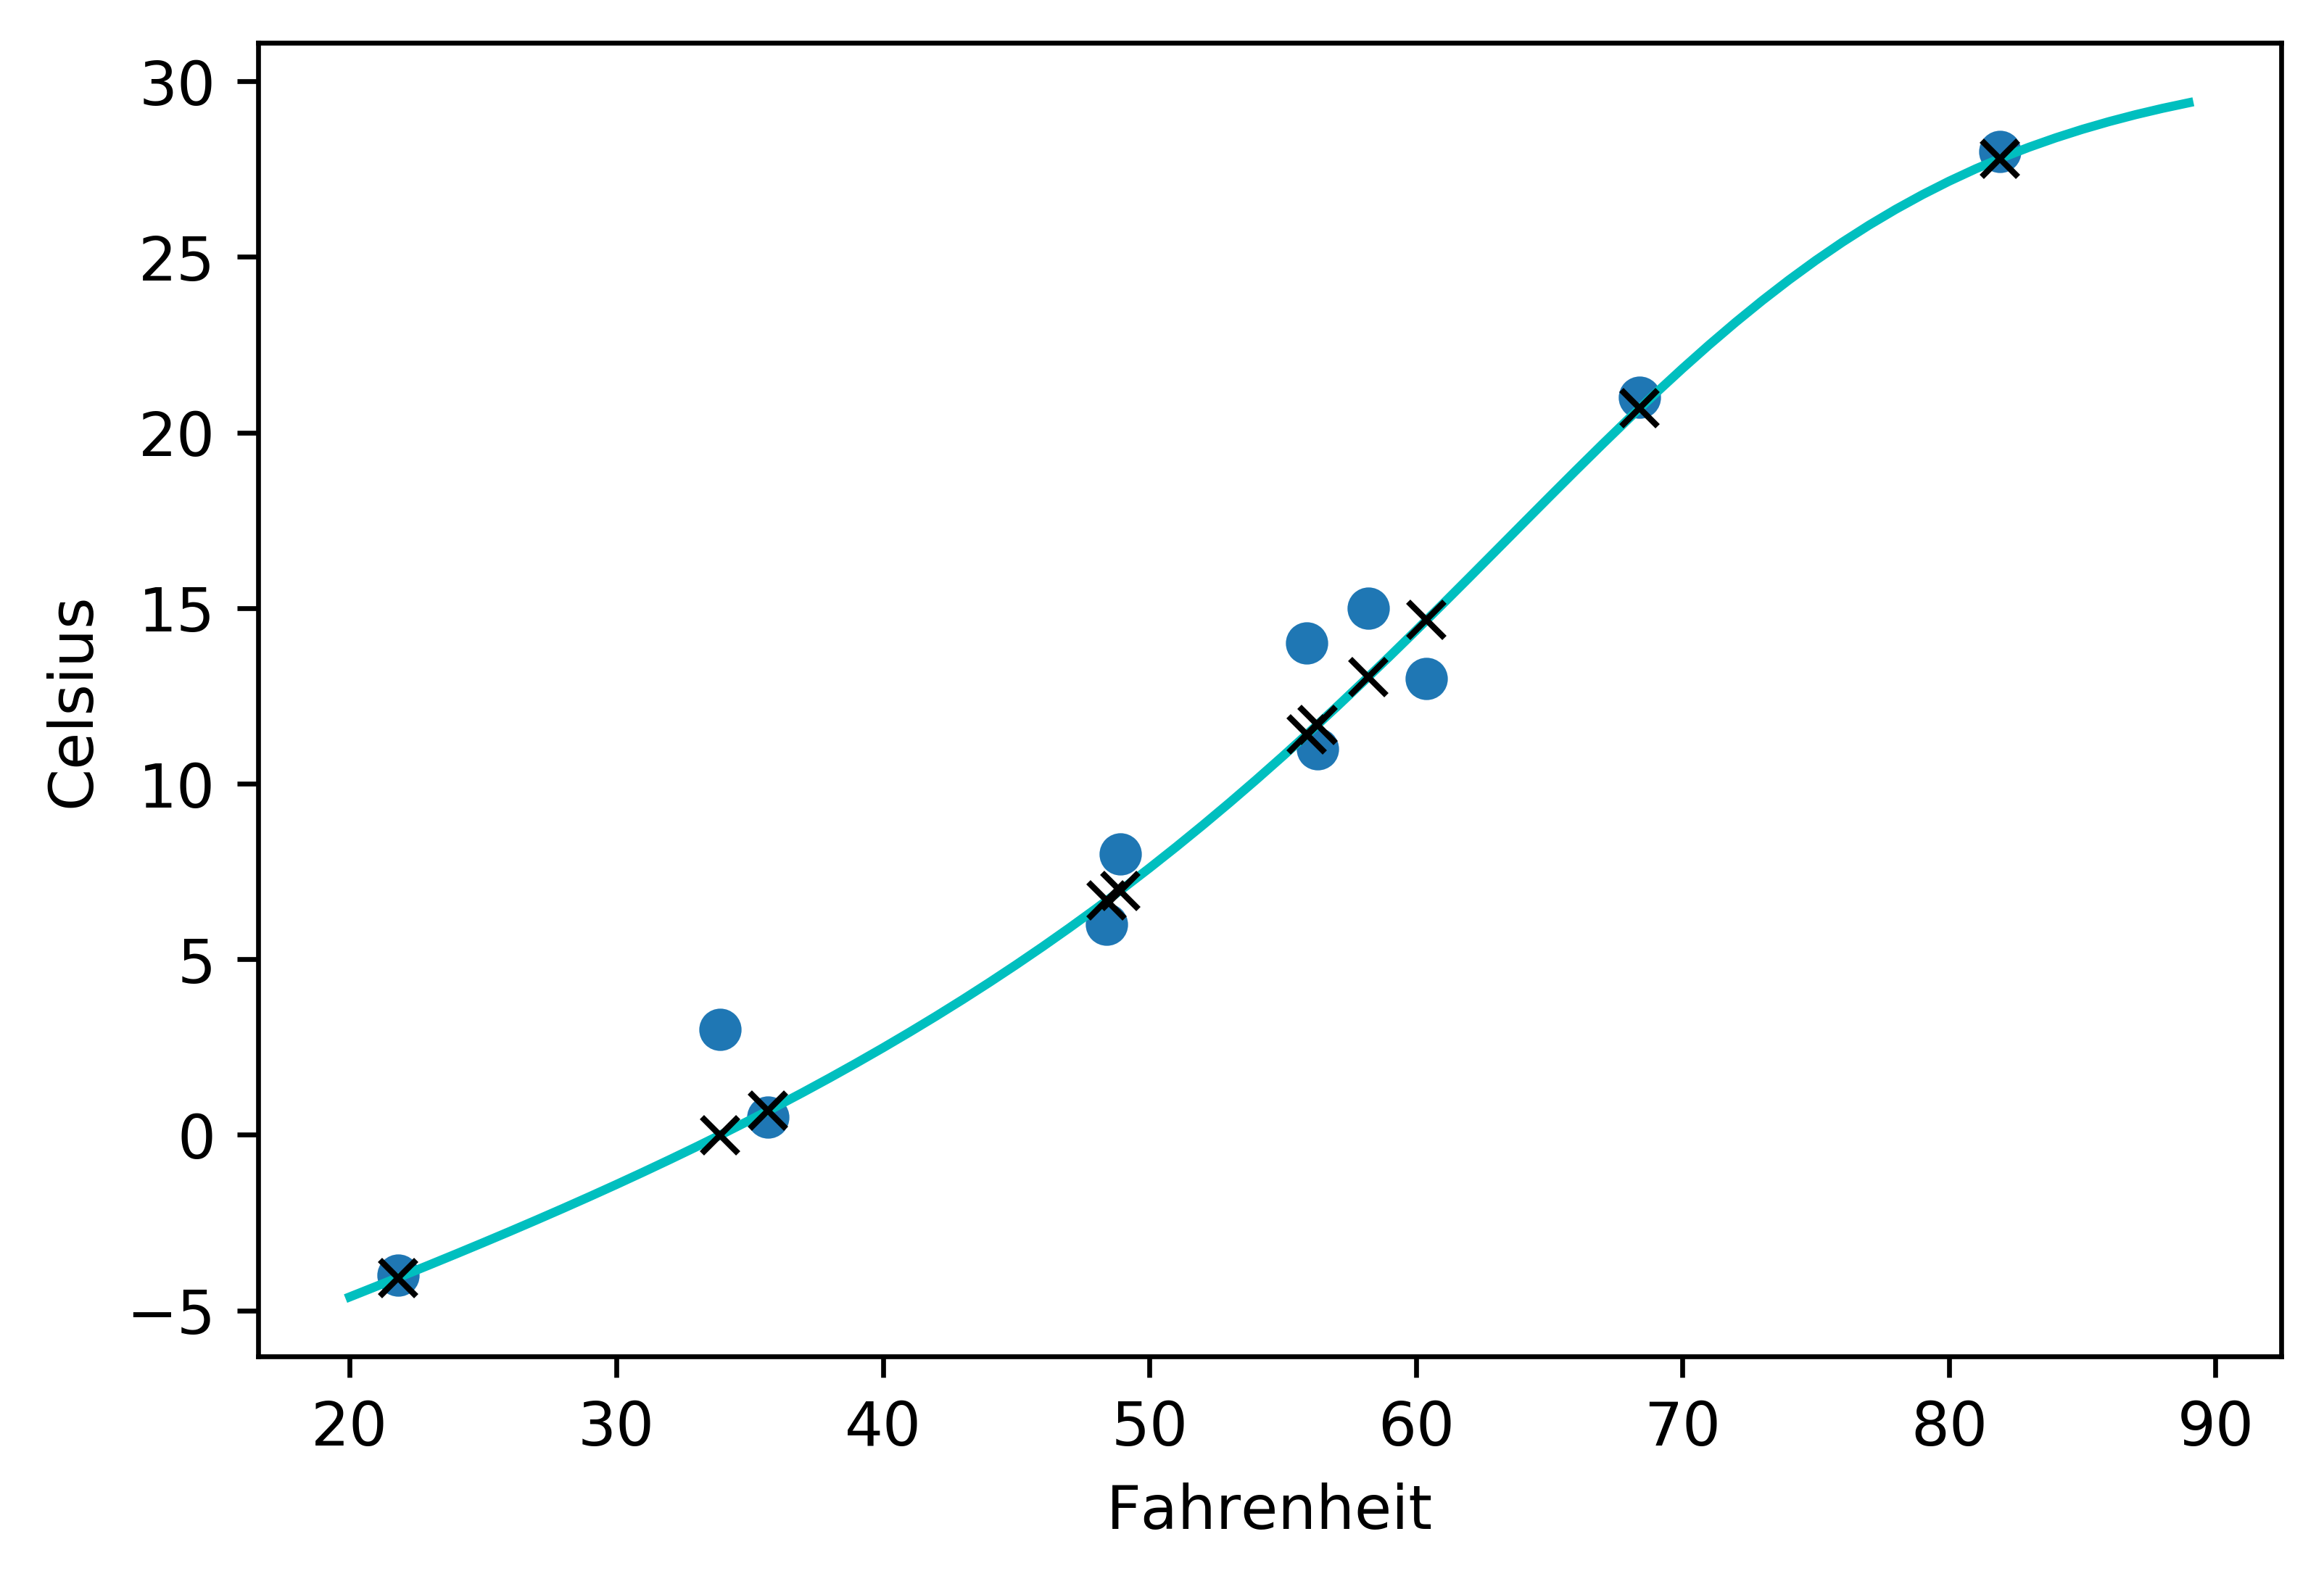

In [44]:
# comparing to linear model 
t_range = torch.arange(20., 90.).unsqueeze(1)
fig = plt.figure(dpi=600) 
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius") 
plt.plot(t_u.numpy(), t_c.numpy(), "o") #input data 
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), "c-") 
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), "kx") # output model

In [45]:
import numpy as np 
import csv

In [46]:
# Excercise with wine data set 
wine_path = "data/tabular-wine/winequality-white.csv"
wineeq_numpy = np.loadtxt(wine_path, dtype=np.float32, delimiter=";", skiprows=1)
print(wineeq_numpy)

# checking if all data  has been read and also getting list of columns 
col_list = next(csv.reader(open(wine_path), delimiter=";"))
print(wineeq_numpy.shape, col_list)


[[ 7.    0.27  0.36 ...  0.45  8.8   6.  ]
 [ 6.3   0.3   0.34 ...  0.49  9.5   6.  ]
 [ 8.1   0.28  0.4  ...  0.44 10.1   6.  ]
 ...
 [ 6.5   0.24  0.19 ...  0.46  9.4   6.  ]
 [ 5.5   0.29  0.3  ...  0.38 12.8   7.  ]
 [ 6.    0.21  0.38 ...  0.32 11.8   6.  ]]
(4898, 12) ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [47]:
# coverting wine data to numpy arrays 
wineeq = torch.from_numpy(wineeq_numpy)
print(wineeq.shape, wineeq.dtype)

torch.Size([4898, 12]) torch.float32


In [48]:
# getting data and target variables 
data = wineeq[:, :-1]
target = wineeq[:, -1]

print(data.shape, target.shape)

torch.Size([4898, 11]) torch.Size([4898])


In [49]:
# normalizing the data  
data_mean = torch.mean(data, dim=0) 
data_var = torch.var(data, dim=0) 

data = (data-data_mean) / torch.sqrt(data_var) 
data

tensor([[ 1.7209e-01, -8.1764e-02,  2.1325e-01,  ..., -1.2468e+00,
         -3.4914e-01, -1.3930e+00],
        [-6.5743e-01,  2.1587e-01,  4.7991e-02,  ...,  7.3992e-01,
          1.3467e-03, -8.2418e-01],
        [ 1.4756e+00,  1.7448e-02,  5.4378e-01,  ...,  4.7502e-01,
         -4.3677e-01, -3.3662e-01],
        ...,
        [-4.2042e-01, -3.7940e-01, -1.1915e+00,  ..., -1.3131e+00,
         -2.6152e-01, -9.0544e-01],
        [-1.6054e+00,  1.1666e-01, -2.8253e-01,  ...,  1.0048e+00,
         -9.6250e-01,  1.8574e+00],
        [-1.0129e+00, -6.7703e-01,  3.7852e-01,  ...,  4.7502e-01,
         -1.4882e+00,  1.0448e+00]])

In [50]:
data_c = data.unsqueeze(1) 
target_c = target.unsqueeze(1)

data_c.shape, target_c.shape

(torch.Size([4898, 1, 11]), torch.Size([4898, 1]))

In [51]:
n_sample = target_c.shape[0]
n_val = int(0.3 * n_sample) 

shuffled_indices = torch.randperm(n_sample)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:] 

data_train = data_c[train_indices]
target_train = target_c[train_indices]

data_val = data_c[val_indices]
target_val =target_c[val_indices]

data_train_un = 0.1 * data_train
target_val_un = 0.1 * target_val

In [52]:
data_train.shape , target_train.shape, data_val.shape, target_val.shape

(torch.Size([3429, 1, 11]),
 torch.Size([3429, 1]),
 torch.Size([1469, 1, 11]),
 torch.Size([1469, 1]))

In [58]:
seq_model = nn.Sequential(OrderedDict([('hidden_linear',  nn.Linear(11,64)),
                                        ('hidden_activation',nn.Tanh()),
                                        ('output_linear', nn.Linear(64,9))]))


training_loop(n_epochs=5000, optimizer=optimizer, model=seq_model, loss_fn=nn.MSELoss(), train_t_u=data_train, val_t_u=data_val, train_t_c=target_train, val_t_c=target_val) 



Epoch 1, Training loss 35.7519 Validation loss 35.1293


KeyboardInterrupt: 